In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
import langgraph
from IPython.display import Image, display

from langsmith import traceable



In [15]:
import os

os.environ["LANGCHAIN_API_KEY"] = "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"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langgraph-freshers"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"



print("API:", os.environ.get("LANGCHAIN_API_KEY"))
print("TRACE:", os.environ.get("LANGCHAIN_TRACING_V2"))
print("PROJECT:", os.environ.get("LANGCHAIN_PROJECT"))

API: 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
TRACE: true
PROJECT: langgraph-freshers


State - state is the central data object that flows through the entire graph and gets updated by each node.

In [16]:
class State(TypedDict):
    query: str
    intent: str
    data: str
    answer: str
    count: int

In [17]:
@traceable
def intent_classifier(state: State):
    print("Classifying intent")
    if "AI" in state["query"]:
        return {"intent": "ai"}
    return {"intent": "general"}


@traceable
def researcher(state: State):
    print("Researcher working")
    return {"data": f"Research data for: {state['query']}"}


@traceable
def writer(state: State):
    print("Writer generating answer")
    return {
        "answer": state.get("answer", "") + f" Answer using ({state['data']})."
    }

def dummy_node(state):
    print("dummy node")
    return {"answer": "dummy node" }


HITL


In [18]:
@traceable
def reviewer(state: State):
    print("\nREVIEW STEP (HITL)")
    print("Generated Answer:\n", state["answer"])

    approval = input("Approve? (yes/no): ")

    if approval.lower() == "yes":
        return {"answer": state["answer"] + " Approved"}
    else:
        return {"answer": "Rejected by human"}

LOOP

In [19]:
@traceable
def increment(state: State):
    return {"count": state.get("count", 0) + 1}


@traceable
def loop_check(state: State):
    print("Checking loop condition...")
    if state["count"] < 2:
        return "call_subgraph"
    return "__end__"

Conditional Routing

In [20]:
@traceable
def route_intent(state: State):
    print("Routing based on intent...")
    if state["intent"] == "ai":
        return "call_subgraph"
    return "__end__"

Subgraph

In [21]:
sub_builder = StateGraph(State)

sub_builder.add_node("researcher", researcher)
sub_builder.add_node("writer", writer)

sub_builder.set_entry_point("researcher")
sub_builder.add_edge("researcher", "writer")
sub_builder.add_edge("writer", "__end__")

subgraph = sub_builder.compile()




In [22]:
@traceable
def call_subgraph(state: State):
    print("Calling subgraph...")
    result = subgraph.invoke(state)
    return result




Main graph

In [23]:
builder = StateGraph(State)

builder.add_node("intent_classifier", intent_classifier)
builder.add_node("call_subgraph", call_subgraph)
builder.add_node("reviewer", reviewer)
builder.add_node("increment", increment)
builder.add_node("dummy", dummy_node)


builder.set_entry_point("intent_classifier")

Flow

In [24]:
builder.add_conditional_edges(
    "intent_classifier",
    route_intent,
    {
        "call_subgraph": "call_subgraph",
        "__end__": "__end__"
    }
)

builder.add_edge("call_subgraph", "reviewer")
builder.add_edge("reviewer", "increment")


builder.add_conditional_edges(
    "increment",
    loop_check,
    {
        "call_subgraph": "call_subgraph",
        "__end__": "__end__"
    }
)

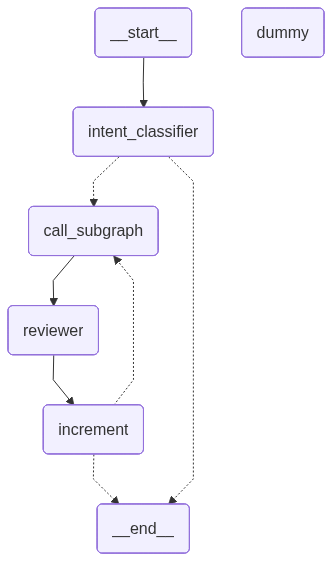

In [25]:

from IPython.display import Image, display
conn = sqlite3.connect("graph.db", check_same_thread=False)
memory = SqliteSaver(conn)

graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
if __name__ == "__main__":
    result = graph.invoke(
        {
            "query": "Explain AI",
            "count": 0
        },
        config={
            "configurable": {
                "thread_id": "1"
            }
        }
    )

    print("\nyes FINAL RESULT:")
    print(result)

Classifying intent
Routing based on intent...
Calling subgraph...
Researcher working
Writer generating answer

REVIEW STEP (HITL)
Generated Answer:
 dummy node Answer using (Research data for: Explain AI).


Checking loop condition...
Calling subgraph...
Researcher working
Writer generating answer

REVIEW STEP (HITL)
Generated Answer:
 dummy node Answer using (Research data for: Explain AI). Approved Answer using (Research data for: Explain AI).
Checking loop condition...

yes FINAL RESULT:
{'query': 'Explain AI', 'intent': 'ai', 'data': 'Research data for: Explain AI', 'answer': 'dummy node Answer using (Research data for: Explain AI). Approved Answer using (Research data for: Explain AI). Approved', 'count': 2}
